# Text Classification on Social Media Commentary

Assignment devoloped by António Romão (up202108704), Guilherme Gonçalves (up202107768) and Pedro Leitão (up202107852) for the Natural Language Processing course at FEUP.

## Table of Contents
1. [Introduction](#1-introduction)
    - 1.1. [Context and Problem Statement](#11-context-and-problem-statement)
    - 1.2. [Assignment Objectives](#12-assignment-objectives)
2. [Data Provenance and Characteristics](#2-data-provenance-and-characteristics)
    - 2.1. [Origin and Collections Methods](#21-origin-and-collection-methods)
    - 2.2. [Annotation Methodology](#22-annotation-methodology)
    - 2.3. [Label Definitions](#23-label-definitions)
    - 2.4. [Initial Processing and Structure](#24-initial-processing-and-structure)
3. [Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis-eda)
    - 3.1. [Dataset Overview and Splits](#31-dataset-overview-and-splits)
    - 3.2. [Class Distribution and Balance](#32-class-distribution-and-balance)
    - 3.3. [Text Length Analysis](#33-text-length-analysis)
        - 3.3.1. [Overall Length Distribution](#331-overall-length-distribution)
        - 3.3.2. [Length Distribution by Class](#332-length-distribution-by-class)
    - 3.4. [Lexical Analysis and Word Distribution](#34-lexical-analysis-and-word-distribution)
        - 3.4.1. [Most Frequent Words (N-grams)](#341-most-frequent-words-n-grams)
        - 3.4.2. [TF-IDF Analysis](#342-tf-idf-analysis)
    - 3.5. [Special Tokens, Artifacts and Language Analysis](#35-special-tokens-artifacts-and-language-analysis)
4. [Data Pre-processing](#4-data-pre-processing)
5. [Feature Extraction and Representation](#5-feature-extraction-and-representation)
6. [Model Training and Selection](#6-model-training-and-selection)
7. [Model Evaluation](#7-model-evaluation)
8. [Error Analysis](#8-error-analysis)
9. [Related Work Comparison](#9-related-work-comparison)
10. [Conclusion](#10-conclusion)

## 1. Introduction

[[go back to top]](#table-of-contents)

This report presents the development and evaluation of Natural Language Processing (NLP) classifiers designed for a specialized text classification task. The introduction is divided into two main parts: first, it establishes the context and outlines the core problem by exploring the nuances of the provided social media commentary dataset; second, it details the specific academic objectives, scope, and technical constraints required for this assignment.

### 1.1. Context and Problem Statement

[[go back to section]](#1-introduction)

The landscape of online discourse is complex, and traditional sentiment analysis, often limited to simple 'positive', 'negative', or 'neutral' labels, is frequently insufficient for capturing the true nature of social media commentary. To better understand how users interact, debate, and communicate online, it is necessary to analyze the rhetorical purpose and communicative intent behind the text. 

The dataset provided for this assignment addresses this need by categorizing social media comments into five distinct, nuanced labels: Argumentative, Informational, Opinion, Expressive, and Neutral. These comments were specifically gathered using the search queries 'politics' or 'US Politics'. To ensure a diverse representation of online behavior, the data was sourced from multiple platforms with varying community norms, specifically YouTube, Hacker News, MetaFilter, Reddit, and BlueSky. The collection spans a timeframe from 2024 up to mid-February 2026.

**Problem Statement**: The core problem to be addressed in this assignment is the development of an effective Natural Language Processing (NLP) pipeline for text classification. The objective is to build robust machine learning classifiers capable of automatically categorizing these political social media comments into one of the five target labels. Successfully solving this problem involves navigating the inherent noise and variability of social media text through careful application of data pre-processing, feature extraction (including both sparse and dense representations), and traditional machine learning algorithms.

### 1.2. Assignment Objectives

[[go back to section]](#1-introduction)

The primary aim of this assignment is to build effective Natural Language Processing (NLP) classifiers for a specific text classification task. To achieve this, the project involves a comprehensive exploration of the standard NLP pipeline, including data pre-processing, feature extraction, and a comparative analysis of sparse versus dense feature representations, such as word embeddings. Prior to model development, a critical objective is to conduct an exploratory data analysis (EDA) to thoroughly understand the dataset, which includes documenting class sizes and word distributions (e.g., TF-IDF) supported by proper visualizations.

A core constraint of this project is the strict focus on "traditional" machine learning algorithms. The models explored will include classifiers such as Naive Bayes, Logistic Regression, Decision Trees, Random Forest, Support Vector Machines (SVM), Multi-Layer Perceptrons (MLP), or XGBoost. The implementation of any deep learning architectures based on Convolutional Neural Networks (CNNs), Recurrent Neural Networks (RNNs), or Transformers is explicitly prohibited for this assignment.

Finally, a rigorous evaluation methodology is required. This involves establishing a simple baseline model to benchmark future developments and reporting classifier performance using appropriate metrics such as Precision, Recall, F1, and macro-F1 scores. We will also undertake a detailed error analysis on the best-performing models to understand the reasons behind misclassifications. Furthermore, the project aims to frame our work by comparing our classifier results with any existing related work on the same problem, placing our achievements in the context of prior published research.

## 2. Data Provenance and Characteristics

[[go back to top]](#table-of-contents)

Before developing our text classifiers, the assignment requires us to establish a clear understanding of our data's provenance and inherent characteristics. To achieve this, we will examine the ADS509 Dataset, which serves as the foundation for this project. This dataset was specifically designed to capture the nuanced nature of social media commentary, moving beyond traditional 'positive', 'negative', or 'neutral' sentiment labels. The following subsections detail the sources, annotation methodology, label definitions, and initial processing steps used to construct this dataset, providing the necessary context for our subsequent exploratory data analysis and feature engineering.

### 2.1. Origin and Collection Methods

[[go back to section]](#2-data-provenance-and-characteristics)

To effectively classify the communicative intent behind online discourse, the data for this assignment was sourced from five distinct social media platforms: YouTube, Hacker News, MetaFilter, Reddit, and BlueSky. By utilizing multiple platforms, the dataset captures a wider variety of community norms and conversational styles. 

The collection focused specifically on political discussions, utilizing the targeted search queries 'politics' or 'US Politics'. The overall timeframe for the collected data ranges from 2024 to mid-February of 2026. However, the exact chronological span varies depending on the specific platform's traffic volume and API rate limits. For example, due to its heavy traffic, the Reddit collection hit daily rate limits and is consequently restricted to posts from just the first two weeks of February 2026. In contrast, data pulled from MetaFilter extends as far back as 2024.

Furthermore, specific structural filtering criteria were applied during the collection process to ensure data quality and balance:
* Posts containing fewer than 10 comments were entirely excluded from the dataset.
* A maximum threshold of 300 comments was extracted from any single post to prevent highly active or viral threads from disproportionately dominating the data distribution.

### 2.2. Annotation Methodology

[[go back to section]](#2-data-provenance-and-characteristics)


The annotation process for this dataset employed a hybrid approach, combining initial human validation with large-scale automated labeling using Large Language Models (LLMs). 

First, a manual pilot annotation phase was conducted to establish a baseline. A sample of 100 comments was independently labeled. These initial human annotations were subsequently compared and revised to resolve disagreements and solidify the labeling criteria.

For the remainder of the dataset, the labeling was scaled up using a Batch API to query three distinct state-of-the-art language models: Gemini Flash 3, Chat GPT 5.1, and Claude Haiku 4.5. 

To ensure the models accurately captured the nuanced definitions of the five classes, a few-shot prompting strategy was utilized. Specifically, the prompt provided to the LLMs included:
* 10 examples of correctly labeled samples to demonstrate the expected output.
* 10 examples of previously incorrectly labeled samples, alongside their corrected labels, to help the models avoid common classification pitfalls.

Finally, a consensus mechanism was applied for quality control. Only comments that achieved agreement from two or more of the three LLMs were retained in the final dataset. The remaining comments that failed to reach this majority consensus were set aside for further evaluation and excluded from this core dataset.

### 2.3. Label Definitions

[[go back to section]](#2-data-provenance-and-characteristics)

The dataset categorizes social media comments into five distinct, nuanced labels, moving beyond simple sentiment analysis. Understanding the boundaries between these classes is crucial for our text classification task:

* **Argumentative:** These comments make specific claims, predictions, or assertions that are supported by reasoning. They often use evidence, anecdotes, or scenarios to build a case. The key distinction from an 'Opinion' is the clear attempt to persuade or explain the reasoning behind a position, rather than just stating it.
* **Informational:** This category includes comments that share facts, data, links, or relevant context. They typically exhibit low emotional affect, aiming solely to inform rather than to convince or react. This includes answering questions with factual content. Unlike 'Argumentative' comments, 'Informational' ones present data without advocating for a specific stance.
* **Opinion:** These comments state a value judgment, stance, or "take" without providing substantial reasoning. Examples include simple assertions like "This is good/bad/wrong/overrated". They differ from 'Argumentative' text by lacking a real attempt to support the claim, and from 'Expressive' text because they do make a specific point rather than just reacting.
* **Expressive:** This label captures emotional reactions, sarcasm, jokes, venting, and exclamations. The primary intent is to express feeling rather than to make a substantive point. It includes performative agreements or disagreements (e.g., "THIS," "lol exactly," "what a joke"). The key distinction from 'Opinion' is the absence of an identifiable stance, consisting purely of affect.
* **Neutral:** This category acts as a catch-all for comments that do not clearly fit into the other four categories. It encompasses clarifying or rhetorical questions, meta-commentary, off-topic remarks, and simple factual questions directed at other users.

### 2.4. Initial Processing and Structure

[[go back to section]](#2-data-provenance-and-characteristics)

Before applying our own specific NLP pre-processing techniques, it is important to acknowledge the initial cleaning steps and structural formatting already performed by the dataset creators. 

**Data Processing Steps:**
To ensure a cleaner baseline for text classification, the following processing actions were executed before the dataset was finalized:
* Approximately 2,000 to 3,000 duplicate comments were removed.
* Any rows containing NaN (Not a Number) values were dropped.
* Emojis were systematically converted into their corresponding text representations using the [emoji package](https://pypi.org/project/emoji/).
* All text was converted to lowercase to maintain uniformity.
* Remaining HTML artifacts were stripped from the comments.
* URL links were replaced with a generic `[URL]` tag to normalize the text and prevent the models from overfitting to specific web addresses.
* Escaped characters (e.g., `&/quot;`) were converted back to their standard text equivalents (e.g., `"`).

**Dataset Structure:**
The resulting dataset consists of two primary features: `text` (the social media comment as a string) and `label` (the assigned numeric class ID). The specific mapping of labels to their corresponding numeric IDs is as follows:
* **0**: Neutral
* **1**: Opinion
* **2**: Argumentative
* **3**: Expressive
* **4**: Informational

It is pre-divided into three standard splits to facilitate model training and evaluation:
* **Train Split:** 49,268 examples.
* **Valid Split:** 10,557 examples.
* **Test Split:** 10,558 examples.

## 3. Exploratory Data Analysis (EDA)

[[go back to top]](#table-of-contents)

In this section, we conduct a comprehensive Exploratory Data Analysis (EDA) on the ADS509 dataset to establish a robust understanding of its underlying characteristics prior to feature extraction and model development. As outlined in the assignment objectives, this analysis quantifies the dataset's scale and examines the distribution of examples across the five nuanced target labels: Neutral, Opinion, Argumentative, Expressive, and Informational. By visually exploring text length variations and word distributions (including the application of TF-IDF) across comments sourced from diverse social media platforms, we aim to uncover lexical patterns and potential class imbalances. These foundational insights will directly justify our subsequent choices in data pre-processing and the selection of appropriate traditional machine learning classifiers.

### 3.1. Dataset Overview and Splits

[[go back to section]](#3-exploratory-data-analysis-eda)

Before diving into feature distributions, it is crucial to verify the foundational structure of our dataset. Based on the dataset card, the data has already been pre-divided into three splits (train, validation, and test) and contains two primary features: the `text` of the social media comment and its corresponding numeric `label`. Furthermore, the dataset creators noted that missing values (NaNs) were already removed during their initial processing. In this section, we load the data and programmatically confirm these expected dimensions and data integrity before proceeding with further analysis.

In [1]:
import pandas as pd

# Load the dataset splits
try:
    df_train = pd.read_parquet('dataset/train-00000-of-00001.parquet')
    df_valid = pd.read_parquet('dataset/valid-00000-of-00001.parquet')
    df_test = pd.read_parquet('dataset/test-00000-of-00001.parquet')
except FileNotFoundError:
    print("Please update the file paths in the read_parquet functions to match your local directory.")

# 1. Verify Dataset Splits
print("--- Dataset Splits Overview ---")
print(f"Training set:   {len(df_train):,} examples")
print(f"Validation set: {len(df_valid):,} examples")
print(f"Test set:       {len(df_test):,} examples")

# 2. Check Dataset Structure and Data Types
print("\n--- Training Data Info ---")
df_train.info()

# 3. Verify the absence of Null values
print("\n--- Missing Values Check (Training Set) ---")
missing_values = df_train.isnull().sum()
print(missing_values)

# Display the first few rows to visually inspect the 'text' and 'label' features
display(df_train.head())

--- Dataset Splits Overview ---
Training set:   49,268 examples
Validation set: 10,557 examples
Test set:       10,558 examples

--- Training Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49268 entries, 0 to 49267
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    49268 non-null  object
 1   label   49268 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 769.9+ KB

--- Missing Values Check (Training Set) ---
text     0
label    0
dtype: int64


,text,label
0,thank you!!!!!!!!!!!,3
1,of course they are attacking her but are perfe...,2
2,i am not aware of the us having the ability in...,1
3,"these senators are so funny, in the preceding ...",2
4,naye face_with_tears_of_joy face_with_tears_of...,3


**Observations:**
The dataset has been successfully loaded and its structure verified. The splits precisely match the expected dimensions (49,268 train; 10,557 valid; 10,558 test). As stated in the dataset documentation, there are no missing values (`NaN`s) to handle. A preliminary inspection of the first few rows confirms that textual pre-processing (such as lowercasing and emoji-to-text conversion) is already present. We can now proceed to analyze the distribution of the target labels.

### 3.2. Class Distribution and Balance

[[go back to section]](#3-exploratory-data-analysis-eda)

A fundamental step in preparing for text classification is understanding the distribution of our target variable. Class imbalance can heavily skew the performance of traditional machine learning models, often causing them to over-predict the majority class. In this section, we map the numeric label IDs back to their corresponding descriptive categories (Neutral, Opinion, Argumentative, Expressive, and Informational) to visualize the balance of our training dataset.

--- Class Distribution (Training Set) ---
Opinion: 15,343 examples (31.14%)
Expressive: 15,333 examples (31.12%)
Argumentative: 11,121 examples (22.57%)
Neutral: 3,949 examples (8.02%)
Informational: 3,522 examples (7.15%)


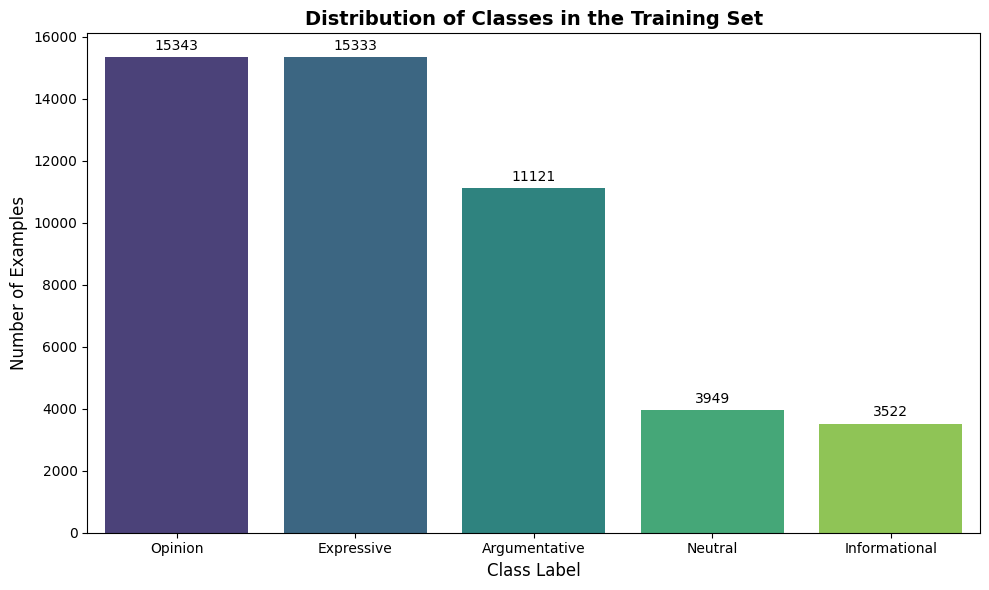

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Map numeric IDs to label names based on the dataset card
id2label = {
    0: 'Neutral',
    1: 'Opinion',
    2: 'Argumentative',
    3: 'Expressive',
    4: 'Informational'
}

# Create a readable label column for EDA
df_train['label_name'] = df_train['label'].map(id2label)

# 2. Calculate counts and percentages
class_counts = df_train['label_name'].value_counts()
class_percentages = df_train['label_name'].value_counts(normalize=True) * 100

print("--- Class Distribution (Training Set) ---")
for label, count in class_counts.items():
    print(f"{label}: {count:,} examples ({class_percentages[label]:.2f}%)")

# 3. Visualize the distribution
plt.figure(figsize=(10, 6))
# Using seaborn for a clean, professional bar chart
ax = sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette='viridis', legend=False)

plt.title('Distribution of Classes in the Training Set', fontsize=14, fontweight='bold')
plt.xlabel('Class Label', fontsize=12)
plt.ylabel('Number of Examples', fontsize=12)

# Add count annotations on top of the bars for clarity
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 8), 
                textcoords = 'offset points')

# Clean up layout
plt.tight_layout()
plt.show()

**Observations:**
The visualization reveals a distinct class imbalance within the training dataset. The "Opinion" (31.14%) and "Expressive" (31.12%) classes heavily dominate the discourse, collectively accounting for over 62% of the data. The "Argumentative" class is also well-represented at 22.57%. Conversely, the "Neutral" (8.02%) and "Informational" (7.15%) classes form a small minority.

This distribution logically aligns with the dataset's provenance: social media discussions gathered using the search queries 'politics' or 'US Politics' naturally skew toward emotional reactions and value judgments rather than the objective sharing of facts or neutral meta-commentary. 

From a machine learning perspective, identifying this imbalance is a critical outcome of our EDA. When training our traditional classifiers, algorithms may become biased toward predicting the majority classes ("Opinion" and "Expressive") at the expense of the minority classes. To mitigate this, we will need to consider strategies such as class weighting during model training, and we must prioritize robust evaluation metrics like macro-F1 over standard accuracy to ensure our models perform well across all communicative intents.

### 3.3. Text Length Analysis

[[go back to section]](#3-exploratory-data-analysis-eda)

Understanding the physical length of the comments within our corpus is a critical step in our Exploratory Data Analysis. Text length directly informs our choices for feature extraction, particularly when determining the maximum vocabulary size or feature limits for sparse representations like TF-IDF or Count Vectorization. Furthermore, analyzing the distribution of comment lengths can reveal inherent structural differences between our target labels; for instance, "Argumentative" comments, which rely on evidence and reasoning, may naturally present as longer texts compared to the shorter, affect-driven statements typical of "Expressive" comments.

#### 3.3.1. Overall Length Distribution

[[go back to subsection]](#33-text-length-analysis)

To begin our text length analysis, we calculate both the character count and the approximated word count (via whitespace splitting) for each comment in the training set. Visualizing these overall distributions using histograms helps us identify the central tendency of the data, as well as any extreme outliers (such as unusually long rants) that might require specialized pre-processing or truncation later in the pipeline.

--- Character Count Statistics ---
count    49268.000000
mean       192.076622
std        317.006453
min          1.000000
25%         50.000000
50%        100.000000
75%        213.000000
max      12768.000000
Name: char_count, dtype: float64

--- Word Count Statistics ---
count    49268.000000
mean        32.760615
std         53.750509
min          1.000000
25%          9.000000
50%         17.000000
75%         36.000000
max       2162.000000
Name: word_count, dtype: float64


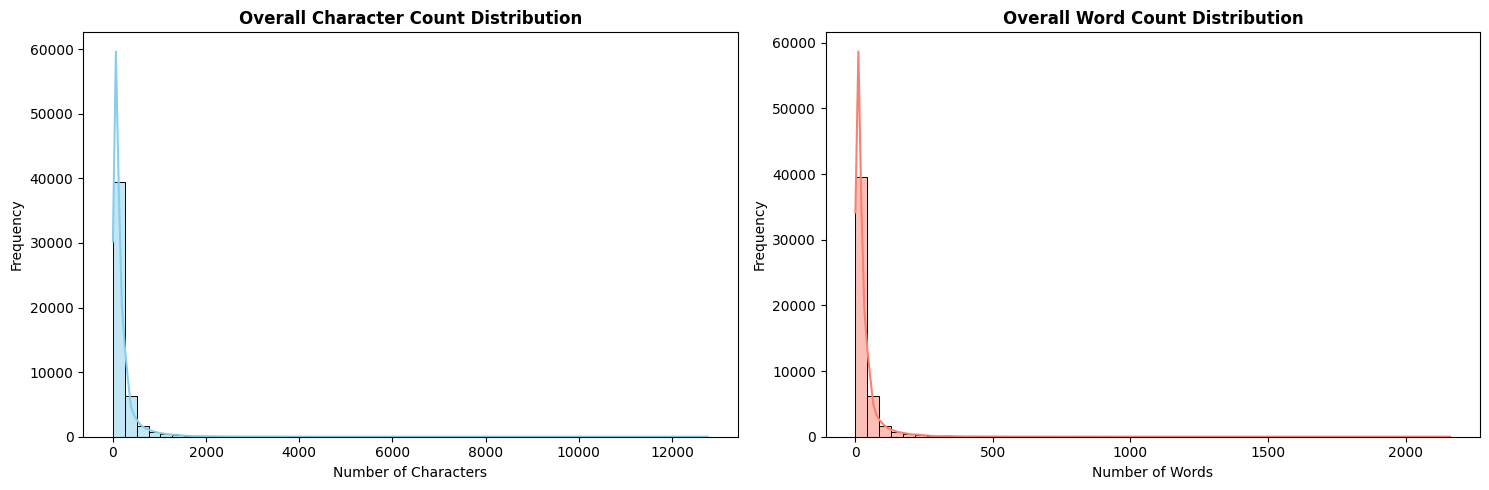

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate character count and word count for the training dataset
df_train['char_count'] = df_train['text'].apply(lambda x: len(str(x)))
df_train['word_count'] = df_train['text'].apply(lambda x: len(str(x).split()))

# Display basic statistical summaries
print("--- Character Count Statistics ---")
print(df_train['char_count'].describe())
print("\n--- Word Count Statistics ---")
print(df_train['word_count'].describe())

# Visualize the overall distributions using histograms
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Character Count Histogram
sns.histplot(df_train['char_count'], bins=50, ax=axes[0], color='skyblue', kde=True)
axes[0].set_title('Overall Character Count Distribution', fontweight='bold')
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Frequency')

# Word Count Histogram
sns.histplot(df_train['word_count'], bins=50, ax=axes[1], color='salmon', kde=True)
axes[1].set_title('Overall Word Count Distribution', fontweight='bold')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Observations:**
The histograms and descriptive statistics reveal that both character and word counts follow a heavily right-skewed distribution. The vast majority of comments are short; the median word count is just 17 words, and 75% of the data falls under 36 words. However, the presence of extreme outliers (with a maximum of 2,162 words and 12,768 characters) pulls the mean significantly higher than the median. 

This distribution is highly characteristic of the diverse social media sources in this dataset (e.g., Reddit, YouTube, BlueSky), where discourse consists primarily of brief, rapid-fire reactions interspersed with occasional long-form rants or detailed explanations. From an NLP pipeline perspective, these extreme outliers suggest that we may need to cap maximum sequence lengths or limit vocabulary sizes during feature extraction (such as when fitting a `CountVectorizer` or `TfidfVectorizer`) to prevent our sparse matrices from expanding exponentially with rare words from these few mega-comments.

#### 3.3.2. Length Distribution by Class

[[go back to subsection]](#33-text-length-analysis)

Having established the overall right-skewed nature of the dataset, we now investigate whether text length varies significantly across our five target labels. Given the specific label definitions provided in the dataset card, it is reasonable to hypothesize that "Argumentative" and "Informational" comments, which require the presentation of facts, reasoning, and context, will inherently possess higher median word counts than "Opinion" or "Expressive" comments, which often consist of brief statements or emotional reactions. To visualize this effectively without the visual distortion caused by the extreme outliers identified in the previous section, we utilize boxplots focusing strictly on the core quartiles of the data.

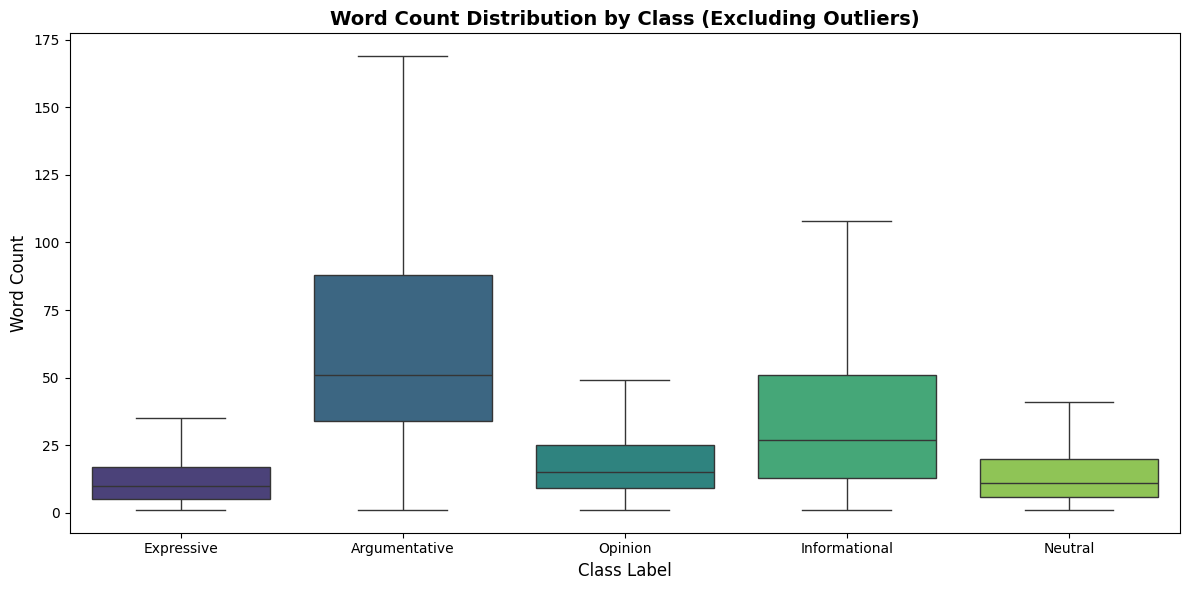

--- Median Word Count per Class ---
label_name
Argumentative    51.0
Informational    27.0
Opinion          15.0
Neutral          11.0
Expressive       10.0
Name: word_count, dtype: float64


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a boxplot to compare word counts across classes
plt.figure(figsize=(12, 6))

# We use showfliers=False to hide the extreme outliers 
# so the core distribution (Interquartile Ranges) is clearly visible.
sns.boxplot(
    x='label_name', 
    y='word_count', 
    data=df_train, 
    palette='viridis',
    hue='label_name',
    legend=False,
    showfliers=False 
)

plt.title('Word Count Distribution by Class (Excluding Outliers)', fontsize=14, fontweight='bold')
plt.xlabel('Class Label', fontsize=12)
plt.ylabel('Word Count', fontsize=12)

plt.tight_layout()
plt.show()

# Calculate and print the median word count per class to confirm the visual trends
print("--- Median Word Count per Class ---")
median_lengths = df_train.groupby('label_name')['word_count'].median().sort_values(ascending=False)
print(median_lengths)

**Observations:**
The boxplot and median word count calculations confirm a significant relationship between a comment's structural length and its specific target label. As hypothesized, the "Argumentative" class exhibits a substantially higher median (51 words) and a much wider interquartile range compared to the other categories. This aligns perfectly with its definition of using evidence, scenarios, and reasoning to build a persuasive case. 

Similarly, the "Informational" class, which focuses on sharing facts and context, shows the second-highest median (27 words). In stark contrast, the "Opinion" (15 words), "Neutral" (11 words), and "Expressive" (10 words) classes are characterized by their brevity, reflecting their nature as quick value judgments, meta-commentary, or purely emotional reactions. 

From an NLP perspective, this is a highly valuable finding. It strongly suggests that "text length" (either raw word count or character count) is a highly discriminative feature. When building our traditional machine learning models (such as Logistic Regression or a Random Forest classifier), appending the raw word count as a dense feature alongside our sparse text representations (like TF-IDF) could notably improve the model's ability to distinguish between "Argumentative" and "Expressive" comments.

### 3.4. Lexical Analysis and Word Distribution

[[go back to section]](#3-exploratory-data-analysis-eda)

Having explored the macro-level characteristics of our dataset, such as class balance and text length, we now shift our focus to the actual content of the comments. A core requirement of this exploratory data analysis is to understand the word distribution across the corpus. By analyzing the most frequent terms (N-grams) and applying techniques like Term Frequency-Inverse Document Frequency (TF-IDF), we can uncover the distinct lexical patterns and vocabulary choices that characterize our five target labels. This lexical analysis will directly inform our subsequent decisions regarding text pre-processing (such as stop-word removal) and feature representation.

#### 3.4.1. Most Frequent Words (N-grams)

[[go back to subsection]](#34-lexical-analysis-and-word-distribution)

Before applying more complex transformations, it is highly beneficial to look at the raw frequency of words (unigrams) and two-word combinations (bigrams) across the dataset. We will use a basic count vectorization approach, initially filtering out standard English stop words, to identify the dominant themes in the political discourse captured in this dataset. Identifying these highly frequent terms helps us verify if platform-specific artifacts or generic political jargon dominate the text, which will guide our feature extraction strategy.

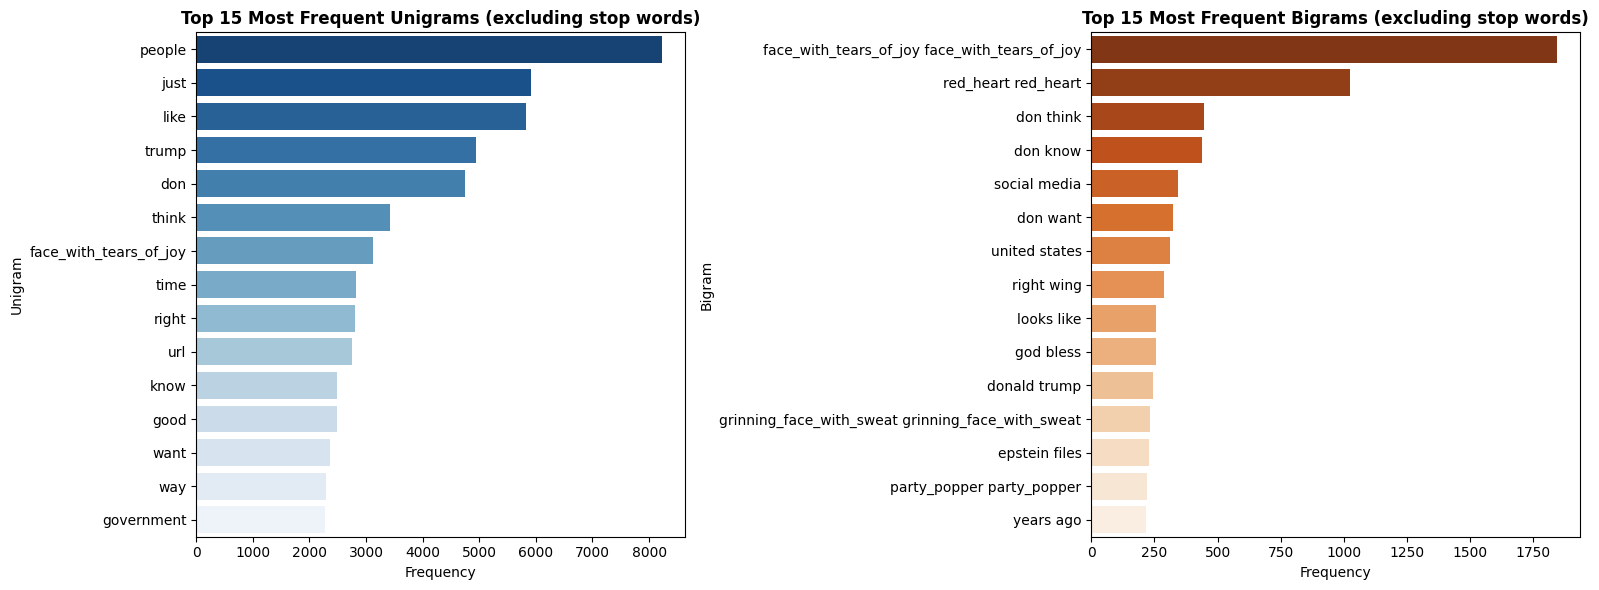

--- Top 5 Unigrams ---
  Unigram  Frequency
0  people       8222
1    just       5908
2    like       5821
3   trump       4940
4     don       4743

--- Top 5 Bigrams ---
                                          Bigram  Frequency
0  face_with_tears_of_joy face_with_tears_of_joy       1843
1                            red_heart red_heart       1024
2                                      don think        448
3                                       don know        439
4                                   social media        344


In [8]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def get_top_n_grams(corpus, n=1, top_k=15):
    """
    Helper function to extract the top k most frequent n-grams from a text corpus.
    We use stop_words='english' to filter out common words like 'the', 'is', 'and'.
    """
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_k]

# Extract top unigrams (1 word) and bigrams (2 words) from the training text
top_unigrams = get_top_n_grams(df_train['text'].dropna(), n=1, top_k=15)
top_bigrams = get_top_n_grams(df_train['text'].dropna(), n=2, top_k=15)

# Convert to DataFrames for easier plotting
df_unigrams = pd.DataFrame(top_unigrams, columns=['Unigram', 'Frequency'])
df_bigrams = pd.DataFrame(top_bigrams, columns=['Bigram', 'Frequency'])

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Unigrams
sns.barplot(x='Frequency', y='Unigram', data=df_unigrams, ax=axes[0], palette='Blues_r', hue='Unigram', legend=False)
axes[0].set_title('Top 15 Most Frequent Unigrams (excluding stop words)', fontweight='bold')

# Plot Bigrams
sns.barplot(x='Frequency', y='Bigram', data=df_bigrams, ax=axes[1], palette='Oranges_r', hue='Bigram', legend=False)
axes[1].set_title('Top 15 Most Frequent Bigrams (excluding stop words)', fontweight='bold')

plt.tight_layout()
plt.show()

# Display the raw data as well
print("--- Top 5 Unigrams ---")
print(df_unigrams.head())
print("\n--- Top 5 Bigrams ---")
print(df_bigrams.head())

**Observations:**
The frequency analysis of unigrams and bigrams provides several critical insights into the dataset's lexical landscape:

1. **Impact of Pre-processing:** The dataset creators explicitly noted that emojis were converted to text and URLs were replaced with a `[URL]` tag. We can see the direct result of this here: `url` is one of the top unigrams, and emoji strings like `face_with_tears_of_joy` and `red_heart` dominate the charts. In fact, repeated emojis (e.g., `face_with_tears_of_joy face_with_tears_of_joy`) are the most frequent bigrams by a massive margin. Given the high volume of the "Expressive" class, these emoji tokens will likely be highly predictive features for our models.
2. **Tokenization Artifacts:** The presence of the unigram `don` (and bigrams like `don think`, `don know`) indicates that punctuation removal during standard tokenization split contractions like "don't". 
3. **Domain Confirmation:** Terms like `trump`, `government`, `united states`, and `right wing` validate the dataset's political scope. 
4. **The Need for Advanced Representation:** Despite removing standard English stop words, colloquial conversational fillers (`just`, `like`, `people`, `think`, `know`) still dominate the top frequencies. Because these terms likely appear uniformly across all classes, they might not be very discriminative for our classifiers. 

This final observation strongly justifies our next step. To filter out these pervasive but uninformative fillers and uncover the truly unique vocabulary of each target label, we must transition from raw counts to Term Frequency-Inverse Document Frequency (TF-IDF) weighting.

#### 3.4.2. TF-IDF Analysis

[[go back to subsection]](#34-lexical-analysis-and-word-distribution)

As observed in our N-gram analysis, raw frequency counts are often dominated by common conversational fillers and ubiquitous emojis, which offer little discriminative power for classification. To uncover the distinctive vocabulary of each target label, we apply Term Frequency-Inverse Document Frequency (TF-IDF) weighting. 

By aggregating all comments within a given class into a single "macro-document" and calculating TF-IDF scores across these five documents, we can penalize terms that are common across the entire political discourse and highlight the unique lexical signatures of each communicative intent. We visualize these class-specific TF-IDF scores using WordClouds, where the size of a word corresponds to its discriminative importance rather than just its raw frequency.

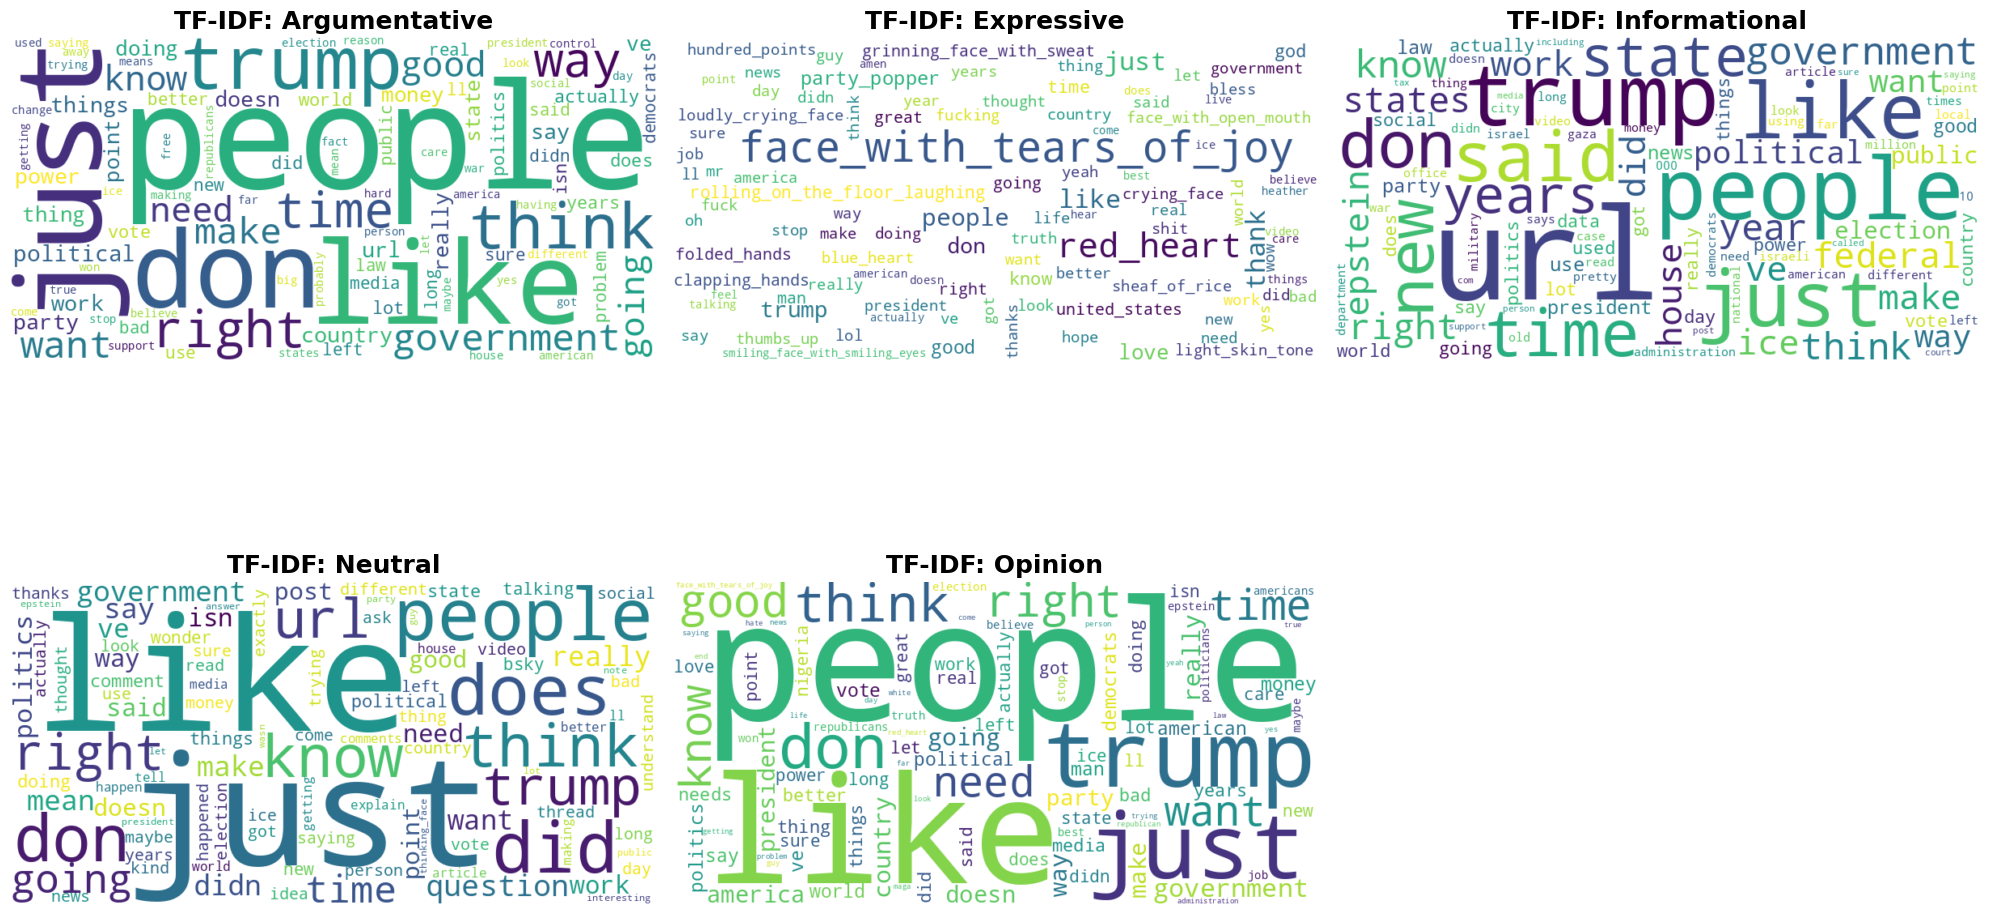

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Combine all text per class to create 5 "macro-documents"
# We drop any lingering NaNs in the text column just to be safe.
class_texts = df_train.dropna(subset=['text']).groupby('label_name')['text'].apply(lambda x: ' '.join(x))

# 2. Initialize and fit the TF-IDF Vectorizer
# We limit to 2000 features to keep the clouds focused on the most important terms
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=2000)
tfidf_matrix = tfidf_vectorizer.fit_transform(class_texts)
feature_names = tfidf_vectorizer.get_feature_names_out()

# 3. Generate WordClouds for each class
# We create a 2x3 grid to hold our 5 visualizations
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, (label, _) in enumerate(class_texts.items()):
    # Get the TF-IDF scores for the current class (row i in the matrix)
    row = tfidf_matrix[i].toarray().flatten()
    
    # Create a dictionary of {word: tf-idf_score} for the WordCloud
    word_scores = {feature_names[j]: row[j] for j in range(len(feature_names)) if row[j] > 0}
    
    # Generate the WordCloud based on these frequencies
    wordcloud = WordCloud(width=800, height=400, 
                          background_color='white', 
                          colormap='viridis',
                          max_words=100).generate_from_frequencies(word_scores)
    
    # Plotting
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f'TF-IDF: {label}', fontsize=18, fontweight='bold')
    axes[i].axis('off')

# Hide the 6th (empty) subplot since we only have 5 classes
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

**Observations:**
The class-specific TF-IDF WordClouds reveal highly distinct lexical signatures that align perfectly with the label definitions provided in the dataset documentation:

1. **Expressive:** This class is overwhelmingly dominated by emoji text strings (e.g., `face_with_tears_of_joy`, `red_heart`, `party_popper`) and reactive language (e.g., "lol", profanities). This mathematically confirms its definition as a category driven by emotional reactions and performative affect rather than substantive points.
2. **Informational:** The most prominent feature here is the `url` token, highlighting the dataset's pre-processing step where links were replaced with this tag. Paired with reporting verbs like `said` and objective nouns like `state`, `new`, and `years`, this solidifies the class's intent to share facts, data, and context.
3. **Neutral:** This category distinctly features meta-commentary vocabulary such as `post`, `thread`, and `video`, alongside question-oriented words (`does`, `did`, `mean`). This directly supports its role as a catch-all for clarifying questions and off-topic remarks.
4. **Opinion vs. Argumentative:** While both classes share generic political vocabulary (`people`, `trump`, `government`), the "Opinion" cloud shows a stronger emphasis on simple value judgments (`good`, `bad`, `right`). 

**Conclusion on Lexical Features:** By applying TF-IDF, we have successfully transformed our raw text into a highly discriminative feature space. The presence of specific tokens (like `url` for Informational or `face_with_tears_of_joy` for Expressive) will serve as incredibly strong signals for our traditional machine learning classifiers (such as Naive Bayes or SVMs) in the modeling phase.

### 3.5. Special Tokens, Artifacts, and Language Analysis

[[go back to section]](#3-exploratory-data-analysis-eda)

During the initial data collection and processing phase, the dataset creators applied specific transformations: URL links were replaced with a standard `[URL]` tag, and emojis were converted into their descriptive text equivalents (e.g., `face_with_tears_of_joy`). Furthermore, the assignment requires us to understand the language coverage of our corpus. 

In this section, we analyze the distribution of these specific artifacts across our five target labels. We hypothesize that "Informational" comments will exhibit a high frequency of URL tags, while "Expressive" comments will be heavily saturated with emoji text, as highlighted by the previous subsection. Additionally, to accurately quantify the presence of non-Latin/multilingual discourse, we use a targeted regular expression to detect specific non-Latin alphabets (such as Cyrillic, Arabic, CJK ideographs, Greek, and Hebrew), ensuring we do not accidentally flag standard English "smart punctuation" or formatting artifacts.

--- Percentage of Comments Containing a URL ---
label_name
Informational    24.503123
Argumentative     5.134430
Neutral           2.886807
Expressive        0.521750
Opinion           0.521410
Name: contains_url, dtype: float64

--- Average Number of Emojis per Comment ---
label_name
Expressive       0.768538
Opinion          0.095157
Neutral          0.051659
Argumentative    0.044061
Informational    0.033220
Name: emoji_count, dtype: float64

--- Percentage of Comments Containing Foreign Scripts (Cyrillic, Arabic, CJK, etc.) ---
label_name
Neutral          0.303874
Expressive       0.280441
Opinion          0.130353
Informational    0.113572
Argumentative    0.062944
Name: has_foreign_script, dtype: float64


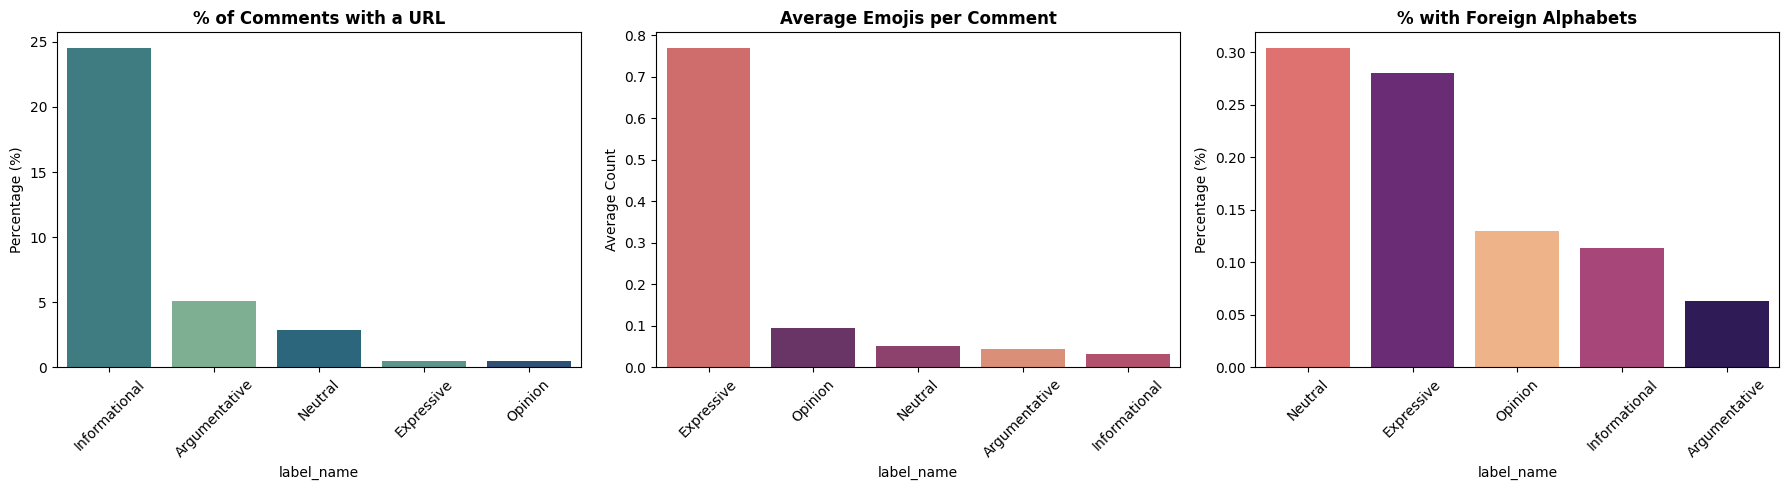

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pandas as pd

# 1. Feature Engineering: Extract Special Tokens & Language Scripts
df_train['contains_url'] = df_train['text'].astype(str).str.contains(r'\[url\]|\burl\b', case=False, regex=True)

def count_emojis(text):
    matches = re.findall(r'\b\w+_\w+\b', str(text))
    return len(matches)

df_train['emoji_count'] = df_train['text'].apply(count_emojis)

# 2. Targeted Foreign Script Detection
# Instead of catching all non-ASCII (which catches smart quotes and dashes), 
# we explicitly target the Unicode blocks for major non-Latin alphabets:
# Cyrillic (\u0400-\u04FF), Arabic (\u0600-\u06FF), Greek (\u0370-\u03FF), 
# Hebrew (\u0590-\u05FF), and CJK/Asian scripts (\u3040-\u30FF, \u4E00-\u9FFF, \uAC00-\uD7AF)
foreign_script_regex = r'[\u0400-\u04FF\u0600-\u06FF\u0370-\u03FF\u0590-\u05FF\u3040-\u30FF\u4E00-\u9FFF\uAC00-\uD7AF]'
df_train['has_foreign_script'] = df_train['text'].astype(str).str.contains(foreign_script_regex, regex=True)

# 3. Calculate Grouped Statistics
url_stats = df_train.groupby('label_name')['contains_url'].mean() * 100
emoji_stats = df_train.groupby('label_name')['emoji_count'].mean()
foreign_stats = df_train.groupby('label_name')['has_foreign_script'].mean() * 100

print("--- Percentage of Comments Containing a URL ---")
print(url_stats.sort_values(ascending=False))
print("\n--- Average Number of Emojis per Comment ---")
print(emoji_stats.sort_values(ascending=False))
print("\n--- Percentage of Comments Containing Foreign Scripts (Cyrillic, Arabic, CJK, etc.) ---")
print(foreign_stats.sort_values(ascending=False))

# 4. Visualize the Results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot URL Distribution
sns.barplot(x=url_stats.index, y=url_stats.values, ax=axes[0], palette='crest', order=url_stats.sort_values(ascending=False).index, hue=url_stats.index, legend=False)
axes[0].set_title('% of Comments with a URL', fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=45)

# Plot Emoji Distribution
sns.barplot(x=emoji_stats.index, y=emoji_stats.values, ax=axes[1], palette='flare', order=emoji_stats.sort_values(ascending=False).index, hue=emoji_stats.index, legend=False)
axes[1].set_title('Average Emojis per Comment', fontweight='bold')
axes[1].set_ylabel('Average Count')
axes[1].tick_params(axis='x', rotation=45)

# Plot Foreign Script Distribution
sns.barplot(x=foreign_stats.index, y=foreign_stats.values, ax=axes[2], palette='magma', order=foreign_stats.sort_values(ascending=False).index, hue=foreign_stats.index, legend=False)
axes[2].set_title('% with Foreign Alphabets', fontweight='bold')
axes[2].set_ylabel('Percentage (%)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Observations:**
The extraction of specific tokens and artifacts provides highly discriminative signals that align perfectly with the dataset's structural definitions:

1. **URLs as Informational Signals:** Nearly 24.5% of "Informational" comments contain a `[URL]` tag, drastically outperforming the other classes. This validates the class's core intent of sharing external facts, data, and context.
2. **Emojis as Expressive Signals:** The "Expressive" class averages 0.77 emojis per comment—nearly 8 to 20 times higher than the other categories. Since this class captures emotional reactions and performative agreements, emojis serve as a dominant vehicle for this communicative intent.
3. **True Multilingual Presence:** By specifically targeting the Unicode blocks for foreign alphabets (e.g., Cyrillic, Arabic, CJK, Greek), we discovered that the presence of non-Latin alphabet scripts is nearly negligible across the entire dataset (peaking at merely 0.30% in the "Neutral" class).

**Conclusion on Exploratory Data Analysis:** Through this comprehensive EDA, we have identified a distinct class imbalance, observed significant structural variations in text length, extracted unique lexical signatures via TF-IDF, and engineered highly predictive artifact features. Appending these dense features (URL presence, Emoji count) to our sparse representations will provide our traditional machine learning classifiers with robust, multidimensional signals to maximize classification performance across these nuanced political intents.

## 4. Data Pre-processing

[[go back to top]](#table-of-contents)

## 5. Feature Extraction and Representation

[[go back to top]](#table-of-contents)

## 6. Model Training and Selection

[[go back to top]](#table-of-contents)

## 7. Model Evaluation

[[go back to top]](#table-of-contents)

## 8. Error Analysis

[[go back to top]](#table-of-contents)

## 9. Related Work Comparison

[[go back to top]](#table-of-contents)

## 10. Conclusion

[[go back to top]](#table-of-contents)